# Participant Status

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Allow pandas to show all columns
pd.set_option('display.max_columns', None)

In [2]:
# Load data from CSV and print summary statistics
master_df = pd.read_csv('../../ppmi_pd/Participant_Status_14Dec2025.csv')
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7905 entries, 0 to 7904
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PATNO               7905 non-null   int64  
 1   COHORT              7905 non-null   int64  
 2   COHORT_DEFINITION   7905 non-null   object 
 3   ENROLL_DATE         4509 non-null   object 
 4   ENROLL_STATUS       7905 non-null   object 
 5   STATUS_DATE         7904 non-null   object 
 6   SCREENEDAM          5816 non-null   float64
 7   ENROLL_AGE          4498 non-null   float64
 8   INEXPAGE            5820 non-null   object 
 9   AV133STDY           7058 non-null   float64
 10  TAUSTDY             7052 non-null   float64
 11  GAITSTDY            7052 non-null   float64
 12  PISTDY              7052 non-null   float64
 13  SV2ASTDY            7052 non-null   float64
 14  NXTAUSTDY           7052 non-null   float64
 15  DPPDSTDY            7052 non-null   float64
 16  DPPROS

In [3]:
# Select relevant columns for analysis
relevant_columns = [
    'PATNO', 'COHORT_DEFINITION', 'ENROLL_DATE', 'ENROLL_STATUS', 'ENROLL_AGE'
]
master_df = master_df[relevant_columns]
master_df = master_df.copy()
master_df.head()

,PATNO,COHORT_DEFINITION,ENROLL_DATE,ENROLL_STATUS,ENROLL_AGE
0,3000,Healthy Control,02/2011,Withdrew,69.1
1,3001,Parkinson's Disease,03/2011,Enrolled,65.1
2,3002,Parkinson's Disease,03/2011,Withdrew,67.6
3,3003,Parkinson's Disease,04/2011,Enrolled,56.7
4,3004,Healthy Control,04/2011,Enrolled,59.4


In [4]:
# Filter out participants with missing enrollment status
filtered_df = master_df.dropna(subset=['ENROLL_STATUS'])
# Filter out participants that has no enroll date
filtered_df = filtered_df.dropna(subset=['ENROLL_DATE'])
# Filter only patients with only enrollment status of "Complete", "Enrolled", "Withdrew", "Withdraw Deceased"
filtered_df = filtered_df[filtered_df['ENROLL_STATUS'].isin(['Complete', 'Enrolled', 'Withdrew', 'Withdraw Deceased'])]
# Filter out patients with Cohort Definition of "SWEDD"
filtered_df = filtered_df[filtered_df['COHORT_DEFINITION'] != 'SWEDD']

# Count how many patients are left after filtering
print(f"Number of patients after filtering: {filtered_df['PATNO'].nunique()}")

Number of patients after filtering: 4369


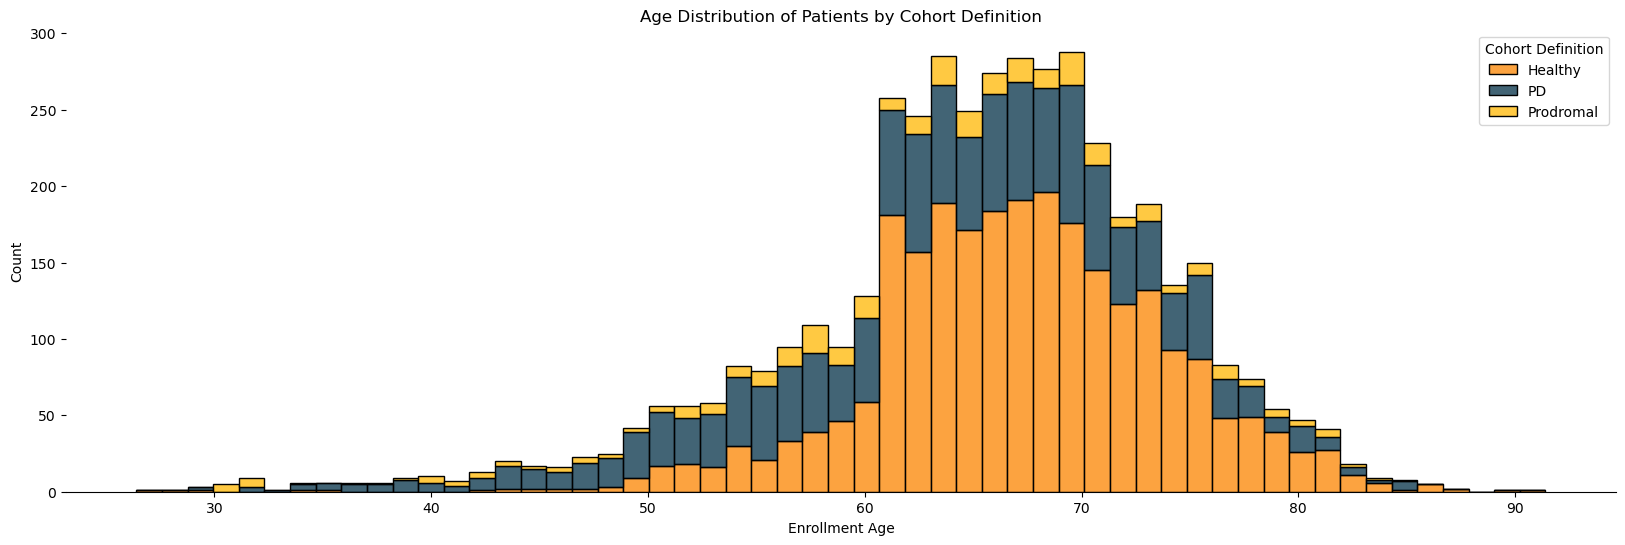

In [ ]:
# make a bar plot of age distribution of patients by cohort definition and includea legend with the following labels:
cohort_labels = {
    'Healthy Control': 'Healthy Control',
    'Prodromal': 'Prodromal',
    'Parkinson\'s Disease': 'Parkinson\'s Disease'
}

custom_palette = {
    'Healthy': '#FFB703',
    'Prodromal': '#FB8500',
    'PD': '#023047'
}

plt.figure(figsize=(20, 6))
sns.histplot(data=filtered_df, x='ENROLL_AGE', hue='COHORT_DEFINITION', multiple='stack', palette=custom_palette)
plt.title('Age Distribution of Patients by Cohort Definition')
plt.xlabel('Enrollment Age')
plt.ylabel('Count')
plt.legend(title='Cohort Definition', labels=[cohort_labels.get(label, label) for label in filtered_df['COHORT_DEFINITION'].unique()])
plt.show()  

/var/folders/62/zjqy8smd44n_h59ql8q_nhy80000gn/T/ipykernel_15719/2959957372.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered_df.groupby(["age_group", "COHORT_DEFINITION"])


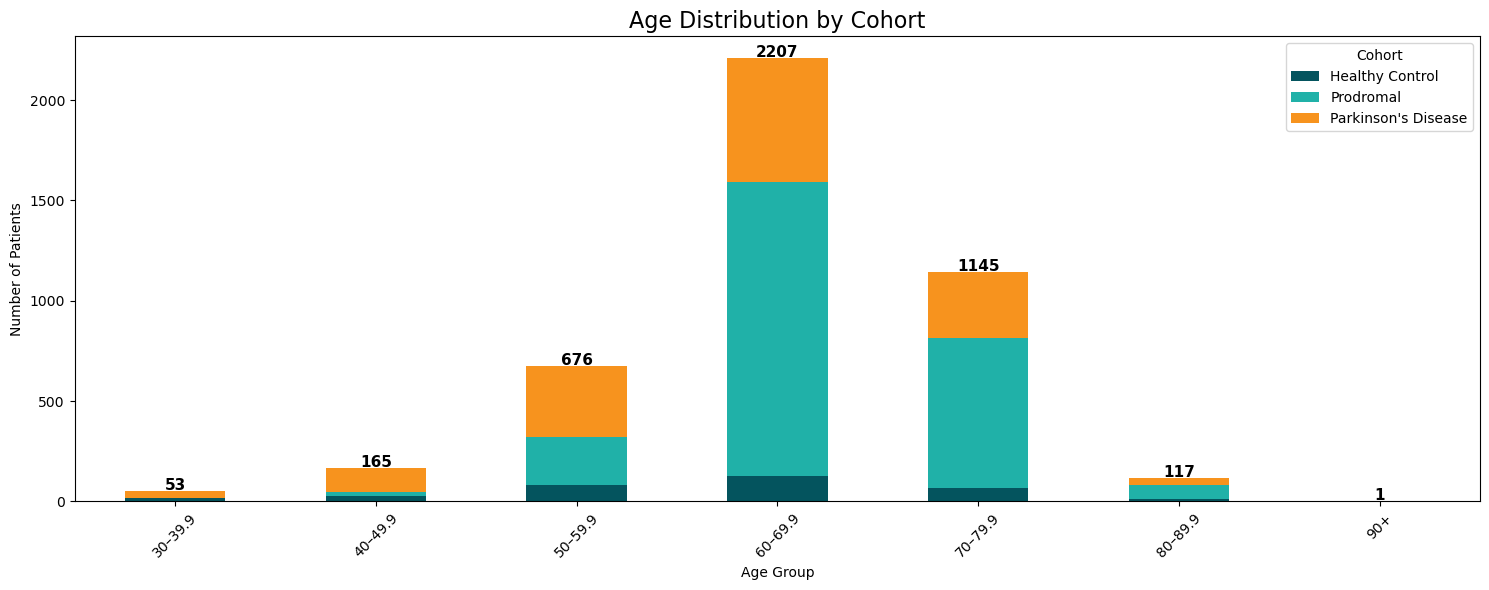

In [12]:
# ==============================
# 1. Create Age Bins
# ==============================

age_bins = [30, 40, 50, 60, 70, 80, 90, 120]
age_labels = [
    "30–39.9",
    "40–49.9",
    "50–59.9",
    "60–69.9",
    "70–79.9",
    "80–89.9",
    "90+"
]

filtered_df["age_group"] = pd.cut(
    filtered_df["ENROLL_AGE"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# ==============================
# 2. Count by Age Group & Cohort
# ==============================

count_df = (
    filtered_df.groupby(["age_group", "COHORT_DEFINITION"])
      .size()
      .reset_index(name="count")
)

# Pivot for stacked plotting
pivot_df = count_df.pivot(
    index="age_group",
    columns="COHORT_DEFINITION",
    values="count"
).fillna(0)

# ==============================
# 3. Plot Stacked Bar Chart
# ==============================

desired_order = [
    "Healthy Control",
    "Prodromal",
    "Parkinson's Disease"
]

pivot_df = pivot_df[desired_order]

custom_palette = {
    'Healthy Control': '#04545E',
    'Prodromal': '#20B1A8',
    'Parkinson\'s Disease': '#F7931E'
}

ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 6),
    color=[custom_palette[c] for c in desired_order]
)

plt.title("Age Distribution by Cohort", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.legend(title="Cohort")
plt.tight_layout()

# ==============================
# 4. Add Total Count Labels
# ==============================

totals = pivot_df.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 5,
        int(total),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.show()

In [8]:
filtered_df['COHORT_DEFINITION'].unique()

array(['Healthy Control', "Parkinson's Disease", 'Prodromal'],
      dtype=object)